In [5]:
! pip install ket-lang[plot]  -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00


In [6]:
from ket import X, Z, H, B, Process, obs, evolve, exp_value, sample
from ket.qulib import draw
from functools import partial
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize

 # Funções auxiliares

In [7]:
def plot_graph(
    graph: list[(int, int)],
    cut: list[int] | None = None,
    n: int | None = None,
):
    if cut is None:
        if n is None:
            raise ValueError("either cut or n must be provided")
        cut = [None] * n
    G = nx.Graph()
    G.add_edges_from(graph)
    node_color = [
        {"0": "#F9F06B", "1": "#1A5FB4"}.get(group, "#9A9996") for group in cut
    ]
    edge_color = []
    for u, v in G.edges():
        if cut[u] != cut[v]:
            edge_color.append("#E01B24")
        else:
            edge_color.append("gray")
    nx.draw(
        G,
        nx.spring_layout(G, seed=42),
        with_labels=True,
        node_color=node_color,
        node_size=2000,
        edge_color=edge_color,
        font_weight="bold",
        width=2,
    )
    plt.show()


def get_cost(state, h):
    n = len(state)
    p = Process(num_qubits=n, execution="batch")
    qs = p.alloc(n)
    for bit, q in zip(state, qs):
        if bit == "1":
            X(q)
    return exp_value(h(qs)).get()

# QAOA Max-Cut

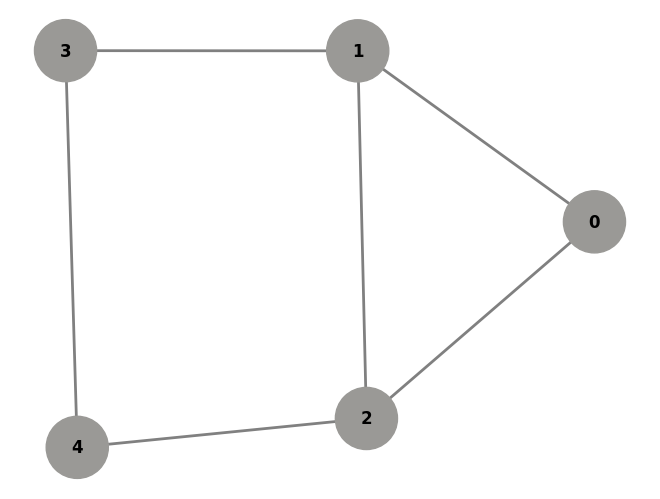

In [8]:
graph = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 4)]
n = 5
plot_graph(graph, n=n)

## Hamiltoniano do Problema

$$H_C = -\frac{1}{2}\sum_{(a,\ b)\in E} 1-Z_aZ_b$$

In [9]:
def cost_h(graph, qubits):
    with obs():
        return -sum(1 - Z(qubits[a]) * Z(qubits[b]) for a, b in graph) / 2

## Hamiltoniano de Mistura

$$H_M = \sum_kX_k$$

In [10]:
def mixer_h(qubits):
    with obs():
        return sum(X(k) for k in qubits)

## Circuito Parametrizado

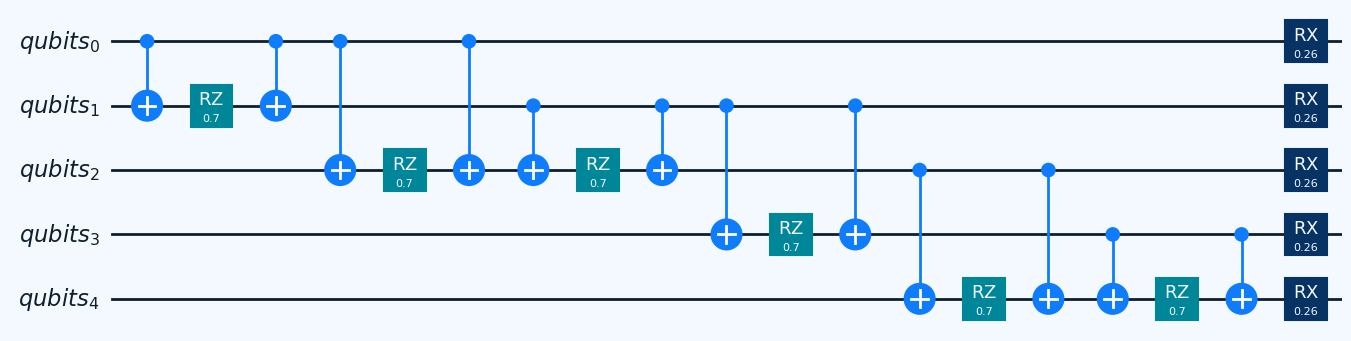

In [11]:
def qaoa_layer(graph, qubits, gamma, beta):
    evolve(gamma * cost_h(graph, qubits))
    evolve(beta * mixer_h(qubits))


draw(partial(qaoa_layer, graph, gamma=0.7, beta=0.13), n)

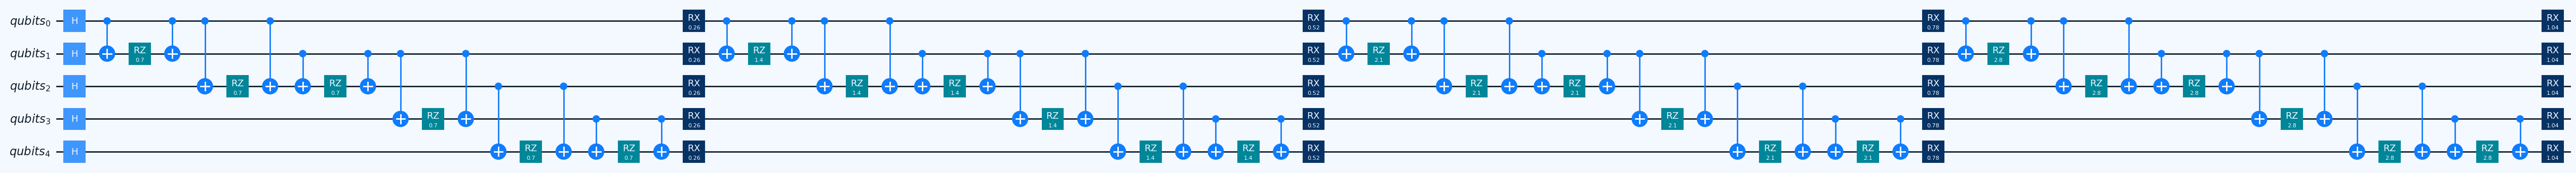

In [12]:
def ansatz(graph, qubits, gamma, beta):
    H(qubits)
    for g, b in zip(gamma, beta):
        qaoa_layer(graph, qubits, g, b)


p = 4
draw(
    partial(
        ansatz,
        graph,
        gamma=[0.7 * i for i in range(1, p + 1)],
        beta=[0.13 * i for i in range(1, p + 1)],
    ),
    n,
    fold=-1,
)

## Optimizando os parameters    

In [13]:
def objective(graph, n, parameters, final=False):
    p = len(parameters) // 2
    gamma = parameters[p:]
    beta = parameters[:p]

    process = Process(num_qubits=n, simulator="dense", execution="batch")
    qubits = process.alloc(n)
    ansatz(graph, qubits, gamma, beta)

    if final:
        return sample(qubits, 100)
    return exp_value(cost_h(graph, qubits)).get()

In [14]:
p = 4
parameters = [0.5 for _ in range(2 * p)]

res = minimize(
    partial(objective, graph, n),
    parameters,
    method="COBYLA",
)

res

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -4.6481725256143145
       x: [ 6.368e-01 -1.333e+00 -3.164e-01  7.162e-01  1.156e+00
            1.119e+00 -5.511e-01 -1.067e+00]
    nfev: 807
   maxcv: 0.0

In [15]:
result = objective(graph, n, res.x, final=True)

result.histogram("bin")

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




|10110>: 23


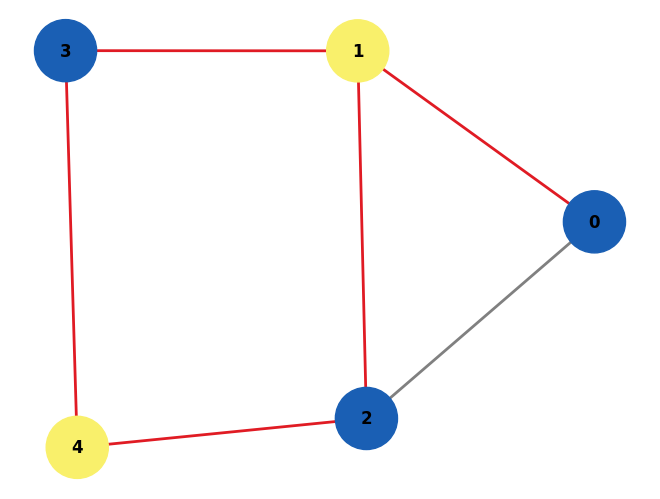

|11001>: 22


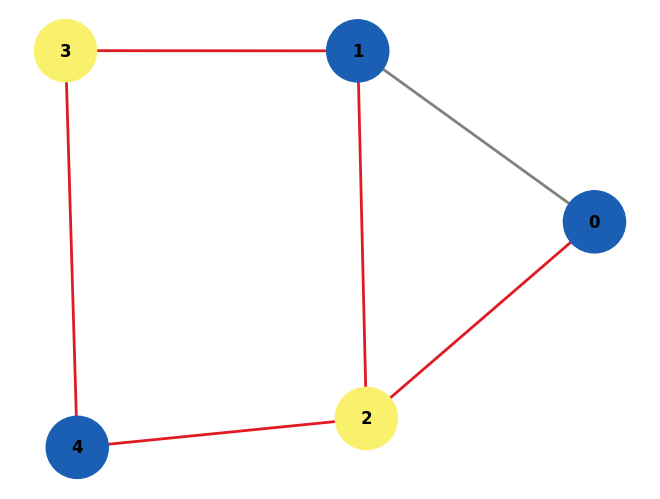

|00110>: 20


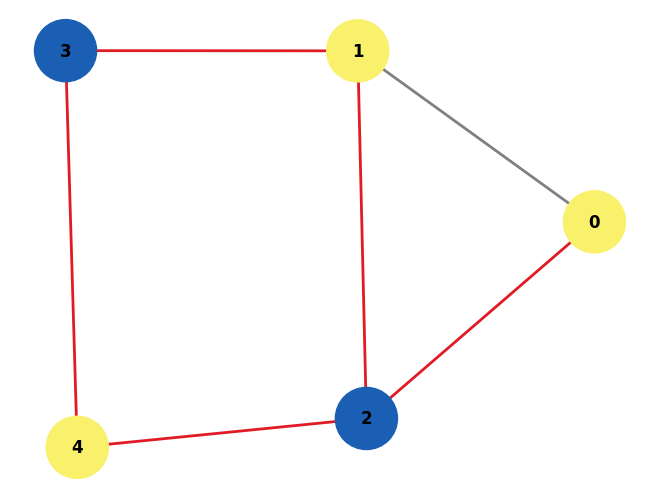

In [16]:
print_n_results = 3
for state, count in sorted(
    result.get().items(),
    key=lambda kv: kv[1],
    reverse=True,
)[:print_n_results]:
    state = f"{state:0{n}b}"
    print(f"|{state}>: {count}")
    plot_graph(graph, state)

# QAOA QUBO - Otimização de Portfólio

$$H(x) = \underbrace{- \sum_{i=1}^n \mu_i x_i}_{\text{Maximizar Retorno}} + \underbrace{q \sum_{i,j} \sigma_{ij} x_i x_j}_{\text{Minimizar Risco}} + \underbrace{\lambda \left( \sum_{i=1}^n x_i - B \right)^2}_{\text{Restrição (Budget)}}$$
$$B(x) = \frac{1-Z_x}{2}$$

In [17]:
def portfolio_h(
    mu: list[float],
    sigma: list[list[float]],
    budget: int,
    q: float,
    qubits,
    lambda_: float = 1,
):

    retorno = sum(i * B(x) for i, x in zip(mu, qubits))
    risco = q * sum(
        sigma[i][j] * B(qubits[i]) * B(qubits[j])
        for i in range(len(qubits))
        for j in range(i + 1, len(qubits))
    )
    restriction = lambda_ * (sum(B(x) for x in qubits) - budget) ** 2

    return -retorno + risco + restriction

In [18]:
mu = [0.31542042, 0.0571331, 0.11430001, 0.30109367]

sigma = [
    [1.08774352e-03, 2.59532811e-04, 1.80247155e-04, 3.21724369e-04],
    [2.59532811e-04, 4.43192629e-04, 7.43211072e-05, 2.27911525e-04],
    [1.80247155e-04, 7.43211072e-05, 3.89444953e-04, 1.37915422e-04],
    [3.21724369e-04, 2.27911525e-04, 1.37915422e-04, 8.75437564e-04],
]

risk = 0.5
budget = 2

## Circuito Parametrizado

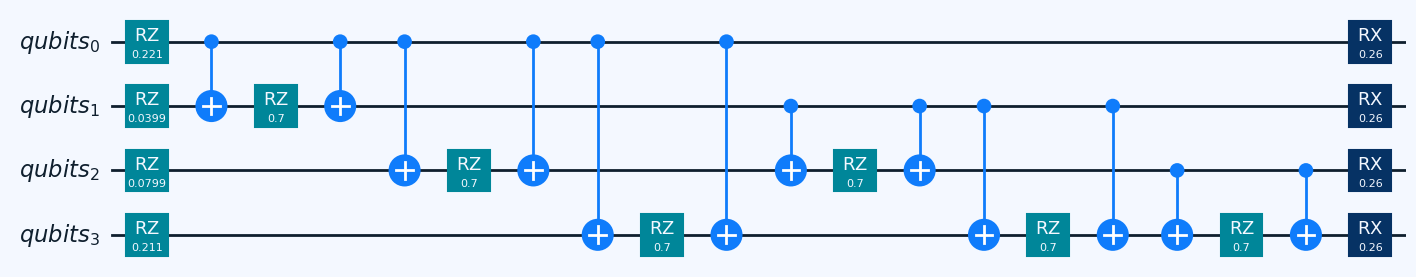

In [19]:
def qaoa_qubo_layer(mu, sigma, budget, risk, qubits, gamma, beta):
    evolve(gamma * portfolio_h(mu, sigma, budget, risk, qubits))
    evolve(beta * mixer_h(qubits))


draw(partial(qaoa_qubo_layer, mu, sigma, budget, risk, gamma=0.7, beta=0.13), len(mu))

In [20]:
def ansatz_qubo(mu, sigma, budget, risk, qubits, gamma, beta):
    H(qubits)
    for g, b in zip(gamma, beta):
        qaoa_qubo_layer(mu, sigma, budget, risk, qubits, g, b)

## Optimizando os parameters    

In [21]:
def objective_qubo(mu, sigma, budget, risk, parameters, final=False):
    p = len(parameters) // 2
    gamma = parameters[p:]
    beta = parameters[:p]
    n = len(mu)

    process = Process(num_qubits=n, simulator="dense", execution="batch")
    qubits = process.alloc(n)
    ansatz_qubo(mu, sigma, budget, risk, qubits, gamma, beta)

    if final:
        return sample(qubits, 100)
    return exp_value(portfolio_h(mu, sigma, budget, risk, qubits)).get()

In [22]:
p = 4
parameters = [0.5 for _ in range(2 * p)]

res = minimize(
    partial(objective_qubo, mu, sigma, budget, risk),
    parameters,
    method="COBYLA",
)

res

 message: Return from COBYLA because the objective function has been evaluated MAXFUN times.
 success: False
  status: 3
     fun: -0.3856829008477921
       x: [ 2.070e-01  7.997e-01  8.337e-01  4.864e-01  9.590e-01
            6.637e-01  1.696e+00  7.225e-01]
    nfev: 1000
   maxcv: 0.0

In [23]:
result = objective_qubo(mu, sigma, budget, risk, res.x, final=True)

result.histogram("bin")

In [24]:
for bitstring, count in sorted(
    result.get().items(),
    key=lambda kv: kv[1],
    reverse=True,
):
    bitstring = f"{bitstring:0{len(mu)}b}"
    print(
        f"|{bitstring}>: <H> = {get_cost(bitstring, partial(portfolio_h, mu, sigma, budget, risk)):+.6f}; count = {count} "
    )

|1001>: <H> = -0.616353; count = 35 
|1100>: <H> = -0.372424; count = 17 
|1010>: <H> = -0.429630; count = 16 
|0101>: <H> = -0.358113; count = 15 
|0011>: <H> = -0.415325; count = 8 
|0110>: <H> = -0.171396; count = 5 
|1011>: <H> = +0.269506; count = 1 
|0000>: <H> = +4.000000; count = 1 
|0111>: <H> = +0.527693; count = 1 
|1110>: <H> = +0.513404; count = 1 
